<div style="text-align: center;">

<h1>Handwritten Digit Recognition</h1>

<h3>Comparing Naive Bayes and Support Vector Machine (SVM)</h3>
    
<br>
    Jupyter Notebook Project · Machine Learning



</div>

<hr>

<div style="text-align: center;">

<p>
This notebook explains how handwritten digits can be recognized using two machine learning models:
<strong>Naive Bayes</strong> and <strong>Support Vector Machine (SVM)</strong>.
</p>

</div>


----------

<h1 style="display: inline-block; border-bottom: 2px solid black; padding-bottom: 3px;">
  Über mich
</h1>

## Wessam Abo Zayed

**Automatisierungstechnik · SPS-/PLC-Programmierung · Data Analyst**
<br>
- Informatiker mit Schwerpunkt Automatisierungstechnik, SPS-/PLC-Programmierung und Data Analytics verbinde ich fundiertes technisches Wissen mit analytischem Denken. 

---

## Kontakt

<div style="text-align: left;">

<table style="margin-left: 0; margin-right: auto;">
  <tr>
    <th style="text-align: center;">Plattform</th>
    <th style="text-align: center;">Link</th>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>E-Mail</strong></td>
    <td style="text-align: left;">
      <a href="mailto:abozayed.wessam@gmail.com">abozayed.wessam@gmail.com</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>LinkedIn</strong></td>
    <td style="text-align: left;">
      <a href="https://www.linkedin.com/in/wessam-abozayed/">linkedin.com/in/wessam-abozayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>GitHub</strong></td>
    <td style="text-align: left;">
      <a href="https://github.com/wessam-abo-zayed">github.com/wessam-abo-zayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>Tableau Public</strong></td>
    <td style="text-align: left;">
      <a href="https://public.tableau.com/app/profile/wessam3726">public.tableau.com/app/profile/wessam3726</a>
    </td>
  </tr>
</table>

</div>


--------

<h1>Index</h1>

<ol>
  <li><a href="#introduction">Introduction</a></li>
  <li><a href="#python-libraries">Python Libraries</a></li>
  <li><a href="#data-analysis">Data Analysis</a></li>
  <li><a href="#machine-learning">Machine Learning</a></li>
  <li><a href="#naive-bayes">Naive Bayes Model Explanation</a></li>
  <li><a href="#svm">SVM Model Explanation</a></li>
  <li><a href="#references">References</a></li>
</ol>


-------

<a id="introduction"></a>
## Introduction

<ol>
<li>This article talk about machine learning in general, and  Naive Bayes and SVM in specific, Which is The Naive Bayes model is one of the easier models using basic probability theory in ML, But Support Vector Machine (SVM) is a more advanced and usually better performing model.</li><br>
<li> We will try to explore those models and explain how to implimint them on real data "Digit estimation".</li>
</ol>

<a id="python-libraries"></a>

## 2. Python Libraries
<ol>
    <li><u><b>Pandas</b></u>:   It's a python library to deal with data frames, to clean, format, and analyse the data. so it's a helpful library to make the data suitable for the machine learning models.</li><br>
    <li><u><b>Numpy:</b></u>  It's is a Python library to deal with arrays, multidimensional and matrices, also to give us the ability and flexibility to handle high-level mathematical functions.</li><br>

<li><u><b>Sklearn:</b></u>It's machine learning library, contain the most ML models and calcualtion, it's like a right hand of python ML models. </li>
- So we can Import:
<ul>
    <li><u><b>RandomizedSearchCV:</b></u> (from sklearn.model_selection import RandomizedSearchCV)<br>
        To build, fit and use the model and make prrediciton. </li>
</ul>    

<ul>
<li><u><b>metrics:</b></u> (from sklearn import metrics) </li>
       To calculate the metrics accuracy and confusion matrix, to know if the model peformanve is good or not.
</ul>
<ul>
<li><u><b>matplotlib:</b></u>   </li>
    It's a visualiazation python lirary.
    
</ul>  
<ol>

-----

<a id="data-analysis"></a>
<h3>3- Data Analysis:</h3>


In [3]:
# Import libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
##################################
# What is our data:
print("- Understand the data:")
print("  --------------------")
##################################
# read the data:
df_train = pd.read_csv('data/mnist_train.csv')
df_test  = pd.read_csv('data/mnist_test.csv')
##################################
# It's important to check how many features we have in the data:
print("- Number if training features:",df_train.shape[1],"  with the Label.")
print("-------------------------------------------------------------")
##################################
# Number of feature in training df should be the same in testing:
print("- Number of features in trining & testing data frames are equal...:",df_train.shape[1] == df_test.shape[1])
print("-------------------------------------------------------------")
#################################
# percent testing DF comparint of training DF:
print("- Percentage of trsining DF samples: ", df_train.shape[0]/(df_train.shape[0]+df_test.shape[0])*100 , " % of the whole data")
print("- percentage of testing  DF samples: ", df_test.shape[0]/(df_train.shape[0]+df_test.shape[0])*100  , "% of the whole data")
print("-------------------------------------------------------------")

- Understand the data:
  --------------------
- Number if training features: 785   with the Label.
-------------------------------------------------------------
- Number of features in trining & testing data frames are equal...: True
-------------------------------------------------------------
- Percentage of trsining DF samples:  85.71428571428571  % of the whole data
- percentage of testing  DF samples:  14.285714285714285 % of the whole data
-------------------------------------------------------------


In [4]:
# Let's check a sample of the data to see the feature and the label:
df_train.head(1)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Let's check the resting DF to compare with training DF:
df_test.head(1)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df_train_F = df_train.loc[:,df_train.columns!="label"] # ML model input called "Features" from training DF: (All columns except label).
df_test_F  = df_test.loc[:,df_test.columns!="label"]   # ML model input to predict from testing DF: (All columns except label).
##################################################
label      = df_train.label
test_label = df_test.label
##################################################
print("-------------------------------------------------------------")
print("- Number if training features (Model Input: to bouild the model.):      ",df_train_F.shape[1])
print("- Number if testing features  (Model Input: to predict&test the model.):",df_test_F.shape[1])
print("-------------------------------------------------------------")


-------------------------------------------------------------
- Number if training features (Model Input: to bouild the model.):       784
- Number if testing features  (Model Input: to predict&test the model.): 784
-------------------------------------------------------------


In [7]:
print(df_train_F.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 784 entries, 1x1 to 28x28
dtypes: int64(784)
memory usage: 358.9 MB
None


In [8]:
label

0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: label, Length: 60000, dtype: int64

- All of these numbers are outputs of the data, and in realthey are a numbers, let's check the output:

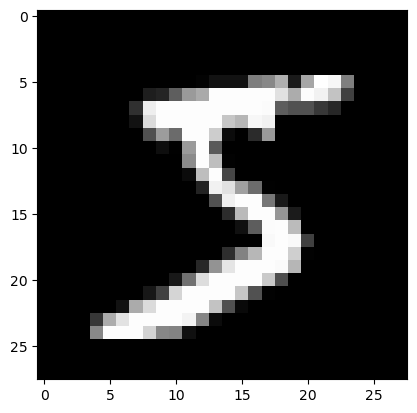

In [9]:
image_feature = df_train_F.iloc[0].values.tolist()
plt.imshow(np.reshape(image_feature, (28,28)), cmap="gray")

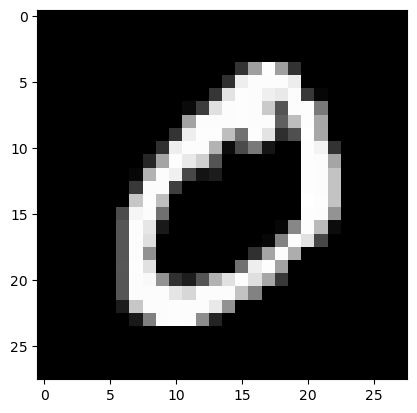

In [10]:
image_feature = df_train_F.iloc[1].values.tolist()
plt.imshow(np.reshape(image_feature, (28,28)), cmap="gray")

-----------------------

<a id="machine-learning"></a>
<h3>4- Machine Learning: </h3>

<h3>1- What is Machine Learning?</h3>
<p>- machine learning is a core sub-area of Artificial Intelligence (AI). ML applications learn from experience (or to be accurate, data) like humans do without direct programming. When exposed to new data, these applications learn, grow, change, and develop by themselves. In other words, machine learning involves computers finding insightful information without being told where to look. Instead, they do this by leveraging algorithms that learn from data in an iterative process.</p>
<img src="images/ML.png" width="700" />

<h3>2- How Does Machine Learning Work?</h3>
<p>- The Machine Learning process starts with inputting training data into the selected algorithm.<br>
   - Training data being known or unknown data to develop the final Machine Learning algorithm. (The type of training data input does impact the algorithm).<br>
   - New input data is fed into the machine learning algorithm to test whether the algorithm works correctly. The prediction and results are then checked against each other.<br>
   - If the prediction and results don’t match, the algorithm is re-trained multiple times until the data scientist gets the desired outcome. This enables the machine learning algorithm to continually learn on its own and produce the optimal answer, gradually increasing in accuracy over time.</p>
<img src="images/ML1.png" width="700" />

<h3>3- What are the Different Types of Machine Learning?</h3>
<ol>
    <li><u><b>Supervised Learning:</b></u></li>
    The label "output" is cleared in the data, we use known or labeled data for the training data. Since the data is known, the learning is, therefore, supervised, i.e., directed into successful execution. The input data goes through the Machine Learning algorithm and is used to train the model. Once the model is trained based on the known data, you can use unknown data into the model and get a new response.<br><br>
   List of top algorithms currently being used for supervised learning are: "<font color="green">Random forest</font>" ,"<font color="green">Linear regression</font>", "<font color="green">Logistic regression</font>", "<font color="green">Decision trees</font>","<font color="green">K-nearest neighbors</font>","<font color="green">Naive Bayes</font>"

<img src="images/Supervised.avif" width="700" /><br>
    <li><u><b>UnSupervised Learning:</b></u></li>
    There is no label, the training data is unknown and unlabeled - meaning that no one has looked at the data before. Without the aspect of known data, the input cannot be guided to the algorithm, which is where the unsupervised term originates from.
    <br><br>
    List of top algorithms currently being used for unsupervised learning are: "<font color="green">K-means clustering</font>" ,"<font color="green">Singular value decomposition</font>", "<font color="green">Fuzzy means</font>", "<font color="green">Hierarchical clustering</font>","<font color="green">Principal component analysis</font>"
<img src="images/UnSupervised.avif" width="700" /><br>
    
</ol>

---------

<a id="naive-bayes"></a>
<center><h1><u>Naive Bayes:</u></h1>

- <h2> What is Naive Bayes Model?</h2>
   - It's a machine learning model which is use probabilities to expect the output, It try to calculate the probability depending on a certain condition, and depending on a prior information as well as other factors too.<br>
    - <b>For example</b>, if the probability of a person saying red is their favourite colour is 30% but 50% if they are in love marriage, then your result will be different based on their marital status.

- <h2> Where can we use it?</h2>
    <ol>
    <li><b><u>Spam Classification:</u></b></li>
    - Given an email, predict whether it is spam or not.
    <li><b><u>Medical Diagnosis:</u></b></li>
    - Given a list of symptoms, predict whether a patient has disease X or not.
    <li><b><u>Weather:</u></b></li>
    - Based on temperature, humidity, etc… predict if it will rain tomorrow.
</ol>

- <h2>Equation for Bayes theorem:</h2><br>
<img src="images/eq1.png"/><br>
- Let’s say A is the event when a person says Red is their favourite colour. and B be the event when the person is married. Thus, P(A | B) is the likelihood of A saying red is their favourite colour when the person is married, similar sense P(B | A) is the likelihood of a person being married when the person says their favourite colour is red.<br>

- But if we have a lot of features,Bayes theorem can be rewritten as:
<img src="images/eq2.webp"/><br>
- The variable y is the label "the class", and Variable X represent the features.
- <u><b>X</b> is given as:</u>
<img src="images/eq3.webp"/><br>
- x1,x2….xn represent the features, So, by substituting for X and expanding using the chain rule we get:<br>
<img src="images/eq4.webp"/><br>
- In our case we have 10 classes, so we need to find the class y with maximum probability:
<img src="images/eq5.webp"/><br>
- Using the above function, we can obtain the class, given the predictors, as folowing:<br>
<img src="images/eq6.png"/><br>


- <h2>Types of Naive Bayes models:</h2>
   Depending on the requirement, you can pick the model accordingly. These models are based on the input data you are working on:
<ol>
    <li><b><u>Multinomial:</u></b> </li>
    - We use it for discrete data "classification". Example: the weather (cloudy, sunny, raining).
    <li><b><u>Gaussian:</u></b> </li>
    - We use it for continuous data which follows a gaussian distribution. Example: the temperature.
    <li><b><u>Binomial:</u></b> </li>
    - We use it when we have data imput as boolean value "yes" or "no".
</ol>

* <h3><u>Naive Bayes Advantages:</u></h3>
<ul>
<li>It is simple and easy to implement.</li>
<li>It doesn’t require as much training data.</li>
<li>It handles both continuous and discrete data.</li>
<li>It is highly scalable with the number of predictors and data points.</li>
<li>It is fast and can be used to make real-time predictions.</li>
<li>It is not sensitive to irrelevant features.</li>
</ul>

* <h3><u>Naive Bayes Disadvantages:</u></h3>
<ul>
<li>Naive Bayes assumes that all predictors (or features) are independent, rarely happening in real life. (This limits the applicability of this algorithm in real-world use cases._</li>
<li>This algorithm faces the ‘zero-frequency problem’ where it assigns zero probability to a categorical variable whose category in the test data set wasn’t available in the training dataset. It would be best if you used a smoothing technique to overcome this issue.</li>
<li>Its estimations can be wrong in some cases, so you shouldn’t take its probability outputs very seriously.</li>
</ul>

- <h2> Naive Bayes Model Implementation: </h2>

In [11]:
# import the model
from sklearn.naive_bayes import BernoulliNB

In [12]:
model = BernoulliNB()
# Fit the model on train dataset
model.fit(df_train_F, label)
predicted_signal = model.predict(df_test_F)

In [13]:
from sklearn import metrics
accuracy_NB = metrics.accuracy_score(test_label, predicted_signal)*100
print("---------------------------------------------------------------")
print("Naive Bayes model accuracy is: %5.2f"  % round(accuracy_NB,2),"%")
print("---------------------------------------------------------------")

---------------------------------------------------------------
Naive Bayes model accuracy is: 84.13 %
---------------------------------------------------------------


- <h2> Naive-Bayes Model accuracy: <font color="green"><b><u>84.13%</u></b></font></h2>


In [14]:
confusion_matrix = metrics.confusion_matrix(test_label, predicted_signal)

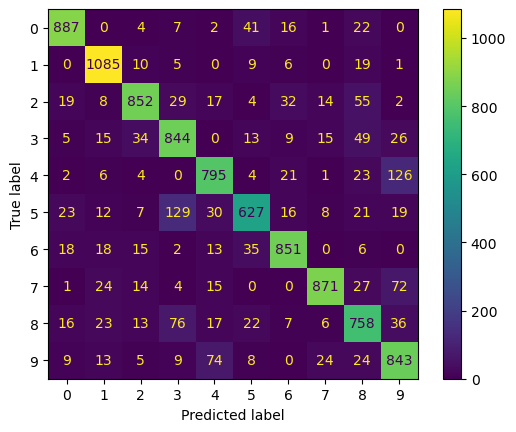

In [15]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [i for i in range(0,10)])
cm_display.plot()
plt.show()

---

<a id="svm"></a>
<center> <h1><U>Support Vector Machines (SVM)</U></h1>

- <b><font color="green"> Support vector machines (SVMs)</font></b>: <br>
  - are supervised learning models with associated learning algorithms that analyze data and recognize patterns, used for classification and regression analysis.<br>
  - Given a set of training examples, each marked for belonging to one of tow categories, an SVM training algorithm builds a model that assigns new examples into one category or the other, making it a non-probabilistic binary linear classifier.
  - An SVM model is a representation of the examples as points in space, mapped so that the examples of the separate categories are divided by a clear gap that is as wide as possible.
  - New examples are then mapped into that same space and predicted to belong to a category based on which side of the gap they fall on.
  - Let’s show the basic intuition SVMs. Imagine the labeled training data below : <br>
  <img src="images/p1.png"/>
 - We can draw a separating “hyperplane” between the classes.
  <img src="images/p2.png"/>
  - But we have many options of hyoerplanes that separate perfectly…
  <img src="images/p3.png"/>
  - We would like to choose a hyperplane that maximizes the margin between classes.
  <img src="images/p4.png"/>
  - The vector points that the margin lines touch are known as Support Vectors.
  <img src="images/p5.png"/>
  - We can expand this idea to non-linearly separable data through the “kernel trick”.
<!--   <img src="images/p5.png"/> -->


<table><tr>
<td> 
    <img alt="Forwarding" src="images/p6.png" width="300">
    <br>
</td>
<td> 
    <img alt="Routing" src="images/p7.png" width="300">
</td>
</tr></table>

- Using the maximum margin separator often gives a pretty good approximation to using all separators weighted by their posterior probabilities, but what to do if there is no separating plane!
<ol>
    <li><b><u>Use a much bigger set of features:</u></b></li>
    - This looks as if it would make the computation too slow!
    <li><b><u>Extend the definition of maximum margin to allow non-separating planes:</u></b></li>
    - Extend the definition of maximum margin to allow non-separating planes.
</ol>

- <h4>What is Slack variables?</h4>
    - Slack variables are constrained to be non-negative. When they are greater than zero they allow us to cheat by putting the plane closer to the datapoint than the margin. So we need to minimize the amount of cheating. This means we have to pick a value for lamba.
  <img src="images/p8.png" width="500"/> <br>
  - And this is a picture of the best plane with a slack variable!
  <img src="images/p9.png" width="500"/> <br>
    

- How to make a plane curved!
 - Fitting hyperplanes as separators is mathematically easy (The mathematics is linear), By replacing the raw input variables with a much larger set of features we get a nice property:
 (<b>Note:</b><font color="green" size=1.5>A planar separator in the high-dimensional space of feature vectors is a curved separator in the low dimensional space of the raw input variables).</font> 
  <img src="images/p10.png" width="300"/>


- If we map the input vectors into a very high-dimensional feature space, surely the task of finding the maximum-margin separator becomes computationally intractable, (<font color="green" size=1.5>The mathematics is all linear, which is good, but the vectors have a huge number of components, So taking the scalar product of two vectors is very expensive.</font>) 
- So the solutoin is the "<font color="blue" size=3><b><u> KERNAL </u></b></font>"

- <h3>What the kernel achieves!</h3>
  - All of the computations that we need to do to find the maximum-margin separator in the high-dimensional feature space can be expressed in terms of scalar products between pairs of datapoints.<br>
  - These scalar products are the only part of the computation that depends on the dimensionality of the high-dimensional space. (<font color="green" size=1.5><b>So if we had a fast way to do the scalar products we would not have to pay a price for solving the learning problem in the high-D space</b>.</font>)<br>
  - The <b>kernel</b> is a magic way of doing scalar products faster than is usually possible.<br><br>
  - For many mappings from a low-D space to a high-D space, there is a simple operation on two vectors in the low-D space that can be used to compute the scalar product of their two images in the high-D space.<br>
  
  
<table><tr>
<td> 
    <img  src="images/p12.png" width="300">
    <br>
</td>
<td> 
    <img  src="images/p11.png" width="300"/>
</td>
</tr></table>

- <h3>Some commonly used kernels!</h3>
    <img  src="images/p13.png" width="500">
    

* <h3><u>SVM Advantages:</u></h3>
<ul>
<li>Gives good results even if there is not enough information about the data. also work well with unstructured data.</li>
<li>Solves complex problems with a convenient kernal solution function.</li>
<li>Relativety good scaling of high dimensional data .</li>
<li>The test performance is very good.</li>
</ul>

* <h3><u>SVM Disadvantages:</u></h3>
<ul>
<li>It's difficult to choose the appropriate kernel solution function.</li>
<li>Training time is long when using larg data sets.</li>
<li>It may be difficult to interpret and understand because of problems caused by personal factores and the weights of cariables.</li>
<li>The weights of the variables are not constant, thus the contribution of each variable to the output is variant.</li>
</ul>

* <h3><u>SVM Parameters:</u></h3>
<ol>
    <li><b><u>C:</u></b> (float, default=1.0) , (Regularization parameter)</li>
    The strength of the regularization is inversely proportional to C. Must be strictly positive. The penalty is a squared l2 penalty.
    <li><b><u>kernel:</u></b> ({'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'}, default='rbf'</li>
    kernel type to be used in the algorithm.
    <li><b><u>degreeint:</u></b> (int, default=3)</li>
    Degree of the polynomial kernel function ('poly'), It's positive.
    
    <li><b><u>gamma:</u></b> ({‘Scale','auto'} or float, default='scale')</li>
    Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    <ol>
        <li><b>if gamma='scale'</b>: Then gamma = (1/(n_features * X.var())).</li>
        <li><b>if gamma='auto' </b>: Then gamma = (1/(n_features)).</li>
        <li><b>if gamma= float </b>: Then gamma must be non-negative.</li>
    </ol>
    <li><b><u>coef0:</u></b> (float, default=0.0)</li>
    Independent term in kernel function. It is only significant in ‘poly’ and ‘sigmoid’.
    <li><b><u>shrinking:</u></b> (boolean, default=True)</li>
    Whether to use the shrinking heuristic.
    <li><b><u>probability:</u></b> (boolean, default=False)</li>
    Whether to enable probability estimates.
    <li><b><u>cache_size:</u></b> (float, default=200)</li>
    cache_sizefloat, default=200.
    <li><b><u>class_weight:</u></b> (dict or 'balanced', default=None)</li>
    Give weight for each class, or “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)).
    <li><b><u>max_iter:</u></b> (int, default=-1)</li>
    Hard limit on iterations within solver, or -1 for no limit.
    <li><b><u>decision_function_shape:</u></b> ({'ovo', 'ovr'}, default='ovr')</li>
   Represent decision function of shape.
      
</ol>

* <h3><u>SVM Attributes::</u></h3>
<ol>
    <li><b><u>class_weight_:</u></b> ndarray of shape (n_classes,)</li>
   Multipliers of parameter C for each class. Computed based on the class_weight parameter.
    <li><b><u>classes_:</u></b> ndarray of shape (n_classes,)</li>
    The classes labels.
    <li><b><u>coef_:</u></b> ndarray of shape (n_classes * (n_classes - 1) / 2, n_features)</li>
    Weights assigned to the features when kernel="linear".
    <li><b><u>fit_status_:</u></b> int</li>
    0 if correctly fitted, 1 otherwise (will raise warning)
    <li><b><u>n_features_in_:</u></b> int</li>
    Number of features seen during fit.
    <li><b><u>n_support_:</u></b> ndarray of shape (n_classes,), dtype=int32</li>
    Number of support vectors for each class.    
</ol>

In [16]:
# Implement the SVM model in Python:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [17]:
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
clf.fit(df_train_F, label)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'


In [18]:
predict_svm = clf.predict(df_test_F)
print(predict_svm)

[7 2 1 ... 4 5 6]


In [19]:
from sklearn import metrics
accuracy_SVM = metrics.accuracy_score(test_label, predict_svm)*100
print("---------------------------------------------------------------")
print("Naive Bayes model accuracy is: %5.2f"  % round(accuracy_SVM,2),"%")
print("---------------------------------------------------------------")

---------------------------------------------------------------
Naive Bayes model accuracy is: 96.65 %
---------------------------------------------------------------


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_label, predict_svm))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.96      0.97       982
           5       0.96      0.96      0.96       892
           6       0.98      0.97      0.98       958
           7       0.93      0.96      0.95      1028
           8       0.96      0.95      0.96       974
           9       0.97      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



- We can let the machine learning defined the best parameters from a range.

<a id="references"></a>
- <h3> References:</h3>
<ul>
    <li><a> https://blog.quantinsti.com/naive-bayes/?utm_source=google&utm_medium=cpc&utm_campaign=dsa_uae&utm_content=&gclid=Cj0KCQiAnNacBhDvARIsABnDa68-3PyC9dh3TDNYGLYvUYuTcSjK_llIgHq3TuE212Q4UZn7aoEt7dAaAp3sEALw_wcB</a></li>
    <li><a>https://scikit-learn.org/stable/modules/naive_bayes.html#bernoulli-naive-bayes</a></li>
    <li><a>https://www.researchgate.net/figure/Support-Vector-Machines-Advantages-and-Disadvantages_tbl2_338950098</a></li>
    <li><a>https://medium.com/@chaudhurysrijani/tuning-of-adaboost-with-computational-complexity-8727d01a9d20</a></li>
</ul>